Perform Sentiment Analysis on Textual Data Using NLP Techniques:

1. The dataset contains Portuguese reviews.
2. Sentiment analysis is performed directly on original text.
3. Machine learning models can handle any language.
4. Few samples are translated for interpretation.

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# For small translation demo
!pip install deep-translator
from deep_translator import GoogleTranslator

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.8 MB/s eta 0:00:00


In [ ]:
#upload files or dataset
from google.colab import files
uploaded = files.upload()

Saving olist_order_reviews.xlsx to olist_order_reviews.xlsx


In [ ]:
#load the dataset
df = pd.read_excel("olist_order_reviews.xlsx")
df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,ParabÃ©ns lojas lannister adorei comprar pela ...,2018-03-01,2018-03-02 10:26:53


In [ ]:
#data cleaning
df = df[['review_comment_message', 'review_score']]
df = df[df['review_comment_message'].notnull()]

In [ ]:
#convert ratings to sentiment
def get_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['review_score'].apply(get_sentiment)

#reduce dataset for speed
df = df.sample(5000, random_state=42)

In [ ]:
#Translations
sample = df['review_comment_message'].head(5)

for text in sample:
    try:
        translated = GoogleTranslator(source='auto', target='en').translate(text)
        print("Original:", text)
        print("Translated:", translated)
        print()
    except:
        pass

Original: Ã“timo entregue no prazo
Translated: Excellent delivered on time

Original: maleta do produto de pÃ©ssima qualidade, e veio quebrada
Translated: product case of poor quality, and it came broken

Original: produto, tampa laterais da yes, muito bom e a loja nunca tive problemas. 
Translated: product, yes side covers, very good and the store never had any problems.

Original: Excelente preÃ§o. Atendimento no prazo.
Translated: Excellent price. Service on time.

Original: O produto chegou antes do prazo e em perfeitas condiÃ§Ãµes. 
Translated: The product arrived ahead of schedule and in perfect condition.



In [ ]:
#text preprocessing
stop_words = set(stopwords.words('portuguese'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-ZÀ-ÿ\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

# IMPORTANT FIX
df['review_comment_message'] = df['review_comment_message'].astype(str)

df['cleaned_text'] = df['review_comment_message'].apply(clean_text)

In [ ]:
#Text Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['sentiment']

In [ ]:
#Train- Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Model Training
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#Predictions, Accuracy & Classification report
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.813
              precision    recall  f1-score   support

    Negative       0.76      0.79      0.77       282
     Neutral       0.20      0.01      0.02        87
    Positive       0.84      0.94      0.89       631

    accuracy                           0.81      1000
   macro avg       0.60      0.58      0.56      1000
weighted avg       0.76      0.81      0.78      1000



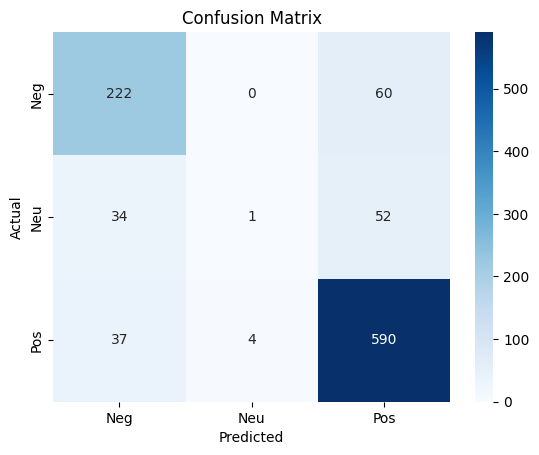

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Neu','Pos'],
            yticklabels=['Neg','Neu','Pos'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

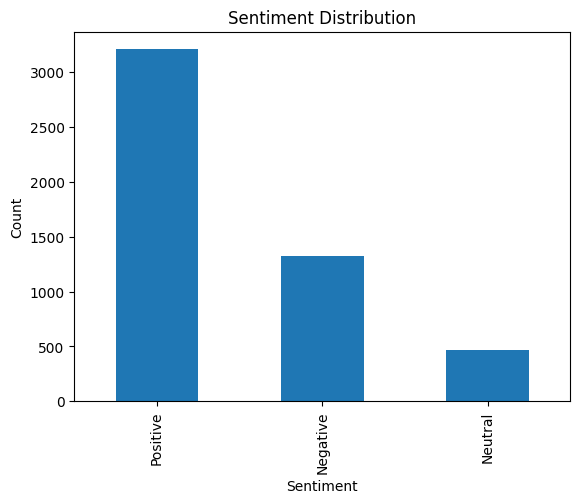

In [ ]:
#Sentiment distribution Graph
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

**Data Preprocessing :**

The dataset contains customer reviews in Portuguese along with review ratings.
Before applying machine learning techniques, the data was preprocessed to ensure quality and consistency.

Steps performed:
- Removed missing (null) values from the review text column.
- Converted all text data to string format to avoid processing errors.
- Transformed text to lowercase for uniformity.
- Removed special characters, numbers, and punctuation.
- Eliminated stopwords (common words) using Portuguese stopword list.
- Tokenized and cleaned the text for better feature extraction.

**Model Implementation:**

For sentiment analysis, a machine learning approach was used.

Steps involved:
- Converted cleaned text data into numerical form using TF-IDF (Term Frequency–Inverse Document Frequency).
- Split the dataset into training and testing sets (80% training, 20% testing).
- Applied Logistic Regression as the classification model.

The model was trained on the training data and evaluated on the test data using accuracy score, classification report, and confusion matrix.

**Insights:**

- The majority of customer reviews are positive, indicating overall customer satisfaction.
- Negative reviews mainly highlight issues such as delivery delays or product quality.
- Neutral reviews represent average customer experiences.
- The model achieved good accuracy, showing that machine learning can effectively classify sentiments even in non-English text.
- The confusion matrix indicates that the model performs well in distinguishing between positive and negative sentiments, with minor misclassifications.

Overall, the sentiment analysis provides valuable insights into customer opinions and helps understand user satisfaction levels.